# `mammos_mumag` quickstart

`mammos_mumag` can compute hysteresis loops of magnetic materials using finite elements.

Requirements:
- `mammos` and `esys-escript`

In [1]:
import mammos_entity as me
import mammos_units as u
import pandas as pd
from mammos_mumag import hysteresis

In [2]:
u.set_enabled_equivalencies(u.magnetic_flux_field())

## Hysteresis simulation

The `hysteresis.run` function computes a hysteresis loop for a homogeneous material with given parameters. We need to pass in a suitable mesh, `mammos_mumag.mesh` provides a sample mesh.

In [3]:
hysteresis_result = hysteresis.run(
    mesh="cube20_singlegrain_msize2",
    Ms=me.Ms(1280000, unit="A/m"),
    A=me.A(7.7e-12, unit="J/m"),
    K1=me.Ku(4300000, unit="J/m3"),
    theta=0,
    phi=0,
    h_start=(10 * u.T).to("A/m"),
    h_final=(-10 * u.T).to("A/m"),
    h_n_steps=20,
)

## Hysteresis result object

The returned `results_hysteresis` object provides a `plot` method to visualize the computed data. `mammos_mumag.hysteresis` only computes half a hysteresis loop, going from `hstart` to `hfinal`. To show a full loop this function mirrors the computed data and plots it twice:

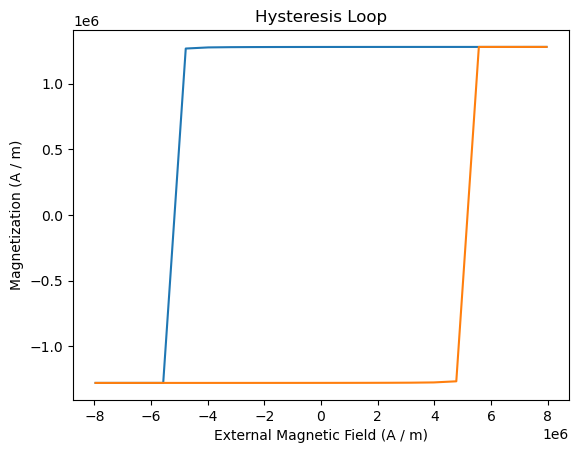

In [4]:
hysteresis_result.plot();

To only see the actual simulation, we can use the flag `duplicate=False`:

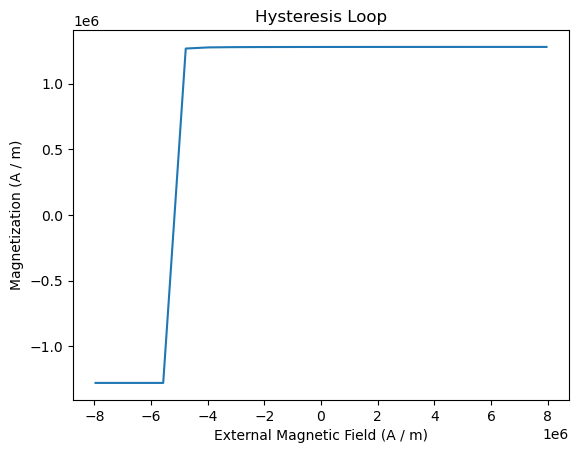

In [5]:
hysteresis_result.plot(duplicate=False);

The results object provides access to:
- the external field `H`
- the magnetization `M` in the direction of the applied field
- the component `Mx`, `My`, `Mz` of the magnetization
- the energy density

In [6]:
hysteresis_result.H

Entity(ontology_label='ExternalMagneticField', value=array([ 7957747.15026276,  7161972.43523649,  6366197.72021021,
        5570423.00518393,  4774648.29015766,  3978873.57513138,
        3183098.86010511,  2387324.14507883,  1591549.43005255,
         795774.71502628,        0.        ,  -795774.71502628,
       -1591549.43005255, -2387324.14507883, -3183098.86010511,
       -3978873.57513138, -4774648.29015766, -5570423.00518393,
       -6366197.72021021, -7161972.43523649, -7957747.15026276]), unit='A / m')

In [7]:
hysteresis_result.M

Entity(ontology_label='Magnetization', value=array([ 1279920.92569655,  1279911.14633934,  1279899.42963877,
        1279885.2268147 ,  1279867.77972873,  1279846.01687668,
        1279818.38389404,  1279782.55594664,  1279734.92828792,
        1279669.66402409,  1279576.79658277,  1279438.13222608,
        1279217.45234696,  1278833.60909754,  1278070.51029595,
        1276161.36652649,  1267635.43145344, -1279885.22584968,
       -1279899.42846665, -1279911.1452972 , -1279920.92579483]), unit='A / m')

In [8]:
hysteresis_result.Mx

Entity(ontology_label='Magnetization', value=array([ -23.54037126,  -25.0451965 ,  -26.7560345 ,  -28.71848504,
        -30.99269791,  -33.65924931,  -36.82966917,  -40.66202659,
        -45.38837715,  -51.36375841,  -59.15966038,  -69.76275253,
        -85.0222662 , -108.88273736, -151.57027633, -250.75175893,
       -861.56501265,   28.53876135,   26.72983079,   25.0250458 ,
         23.51679169]), unit='A / m')

In [9]:
hysteresis_result.My

Entity(ontology_label='Magnetization', value=array([  -48.9635178 ,   -52.0457853 ,   -55.54281008,   -59.54464247,
         -64.16984798,   -69.57549466,   -75.97863179,   -83.68435754,
         -93.13691972,  -105.00949446,  -120.37511784,  -141.05920632,
        -170.42606819,  -215.51717585,  -294.12895559,  -469.64559154,
       -1433.18253466,    59.01421681,    55.28635356,    51.8495188 ,
          48.99411012]), unit='A / m')

In [10]:
hysteresis_result.Mz

Entity(ontology_label='Magnetization', value=array([ 1279920.92569655,  1279911.14633934,  1279899.42963877,
        1279885.2268147 ,  1279867.77972873,  1279846.01687668,
        1279818.38389404,  1279782.55594664,  1279734.92828792,
        1279669.66402409,  1279576.79658277,  1279438.13222608,
        1279217.45234696,  1278833.60909754,  1278070.51029595,
        1276161.36652649,  1267635.43145344, -1279885.22584968,
       -1279899.42846665, -1279911.1452972 , -1279920.92579483]), unit='A / m')

In [11]:
hysteresis_result.energy_density

Entity(ontology_label='EnergyDensity', value=array([-16794046.39939273, -15514130.21974726, -14234224.74917092,
       -12954332.18513003, -11674455.37178373, -10394598.05726379,
        -9114765.28465126,  -7834964.0056009 ,  -6555204.08037736,
        -5275499.98242484,  -3995873.86585082,  -2716361.46928677,
        -1437024.49582884,   -157979.70553049,   1120520.7665673 ,
         2397803.50265979,   3671036.31564498, -12954332.18511862,
       -14234224.74916488, -15514130.2197436 , -16794046.39939053]), unit='J / m3')

The attribute `configuration_type` contains a list of indices that refer to saved magnetization field configurations. We will use this information later.

In [12]:
hysteresis_result.configuration_type

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2])

We can also get the hysteresis data as a pandas dataframe in SI units:

In [13]:
hysteresis_result.dataframe

,configuration_type,H,M,Mx,My,Mz,energy_density
0,1,7.957747e+06,1.279921e+06,-23.540371,-48.963518,1.279921e+06,-1.679405e+07
1,1,7.161972e+06,1.279911e+06,-25.045197,-52.045785,1.279911e+06,-1.551413e+07
2,1,6.366198e+06,1.279899e+06,-26.756035,-55.542810,1.279899e+06,-1.423422e+07
3,1,5.570423e+06,1.279885e+06,-28.718485,-59.544642,1.279885e+06,-1.295433e+07
4,1,4.774648e+06,1.279868e+06,-30.992698,-64.169848,1.279868e+06,-1.167446e+07
5,1,3.978874e+06,1.279846e+06,-33.659249,-69.575495,1.279846e+06,-1.039460e+07
6,1,3.183099e+06,1.279818e+06,-36.829669,-75.978632,1.279818e+06,-9.114765e+06
7,1,2.387324e+06,1.279783e+06,-40.662027,-83.684358,1.279783e+06,-7.834964e+06
8,1,1.591549e+06,1.279735e+06,-45.388377,-93.136920,1.279735e+06,-6.555204e+06
9,1,7.957747e+05,1.279670e+06,-51.363758,-105.009494,1.279670e+06,-5.275500e+06


We can generate a table in alternate units:

In [14]:
df = pd.DataFrame(
    {
        "mu0_H": hysteresis_result.H.q.to(u.T),
        "J": hysteresis_result.M.q.to(u.T),
    },
)
df.head()

,mu0_H,J
0,10.0,1.608396
1,9.0,1.608384
2,8.0,1.608369
3,7.0,1.608351
4,6.0,1.608329


## Visualizing magnetization configurations

To plot the hysteresis loop (including the available configurations), run

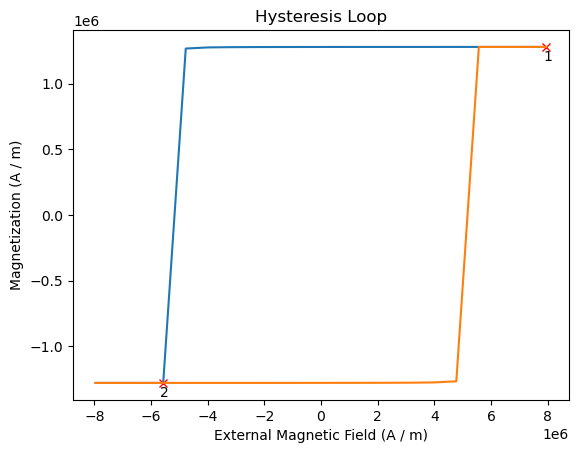

In [15]:
hysteresis_result.plot(configuration_marks=True);

We can get the location of the saved configurations from the attribute `configurations`:

In [16]:
hysteresis_result.configurations

{1: PosixPath('/home/petrocch/repo/mammos/mammos-mumag/examples/hystloop/hystloop_0001.vtu'),
 2: PosixPath('/home/petrocch/repo/mammos/mammos-mumag/examples/hystloop/hystloop_0002.vtu'),
 3: PosixPath('/home/petrocch/repo/mammos/mammos-mumag/examples/hystloop/hystloop_0003.vtu')}

To inspect the configurations more conveniently directly in the notebook we can use the `plot_configuration` function of `hysteresis_result`. We need to pass the index and get an interactive 3D plot (using pyvista):

In [17]:
hysteresis_result.plot_configuration(1)

Widget(value='<iframe src="http://localhost:38093/index.html?ui=P_0x7f9b313a3450_0&reconnect=auto" class="pyvi…

 JS Error => TypeError: `target` argument of Proxy must be an object, got null


Note: the small object size is a consequence of the empty sphere around the cube.